# Ordering Sensitivity

In [ ]:
# Optional: ensure repo root on sys.path if running without installation
import sys, os, pathlib
repo_root = pathlib.Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Using repo root:', repo_root)

In [2]:
# Imports
import os, yaml, time, random, torch
from graphallocbench.train_utils.general import train, train_parallel
from graphallocbench.constants import ALLOWED_DEVICES
from pathlib import Path
print('ALLOWED_DEVICES:', ALLOWED_DEVICES)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


ALLOWED_DEVICES: ['cpu']


In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
start = time.time()
for seed in range(5):
    print(f"Training Seed {seed}")
    train("../train_config/GraphAllocBench-v2/train_problem_5d_arch-0.yml", project_name='GraphAllocBench-Ordering', device=device, seed=seed)
print(f'Training finished in {time.time()-start:.2f}s')

In [ ]:
# Single training example (fast)
device = 'cuda:0' if (torch.cuda.is_available()) else 'cpu'
print('Using device:', device)
start = time.time()
for seed in range(5):
    print(f"Training Seed {seed}")
    train("../train_config/GraphAllocBench-v2/train_problem_5e_arch-0.yml", project_name='GraphAllocBench-Ordering', device=device, seed=seed)
print(f'Training finished in {time.time()-start:.2f}s')

Seed 4: 100%|██████████| 20/20 [01:57<00:00,  5.86s/it]

Fluctuation Standard Deviation: 0.01189413858204028
Coefficient of Variation: 0.018710552968257438


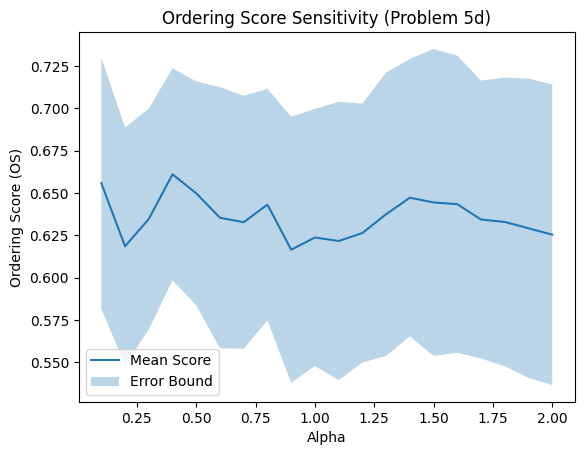

In [9]:
from graphallocbench.evaluation.utils import calculate_ordering_score
from graphallocbench.city_env import CityPlannerEnv
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

env = CityPlannerEnv('config/problems/problem_5d.yml')

alpha_range = [alpha / 10 for alpha in range(1, 21)]
all_scores = []

# Collect scores for seeds 0-4
for seed in range(5):
    scores = []
    for alpha in tqdm(alpha_range, desc=f"Seed {seed}"):
        scores.append(calculate_ordering_score(env, model_path=f'models/GraphAllocBench-Ordering/arch-0/problem_5d/{seed}/model_step_1000000.zip', alpha=alpha))
    all_scores.append(scores)

# Calculate mean and error bounds
all_scores = np.array(all_scores)
mean_scores = np.mean(all_scores, axis=0)
std_scores = np.std(all_scores, axis=0)

fluctuation_std = np.std(mean_scores)
print(f"Fluctuation Standard Deviation: {fluctuation_std}")
cv = fluctuation_std / np.mean(mean_scores)
print(f"Coefficient of Variation: {cv}")
# Plot mean and error bounds
plt.title("Ordering Score Sensitivity (Problem 5d)")
plt.xlabel("Alpha")
plt.ylabel("Ordering Score (OS)")
plt.plot(alpha_range, mean_scores, label='Mean Score')
plt.fill_between(alpha_range, mean_scores - std_scores, mean_scores + std_scores, alpha=0.3, label='Error Bound')
plt.legend()
plt.show()

Seed 4: 100%|██████████| 20/20 [02:05<00:00,  6.26s/it]

Fluctuation Standard Deviation: 0.007262259293491113
Coefficient of Variation: 0.009490744435346895


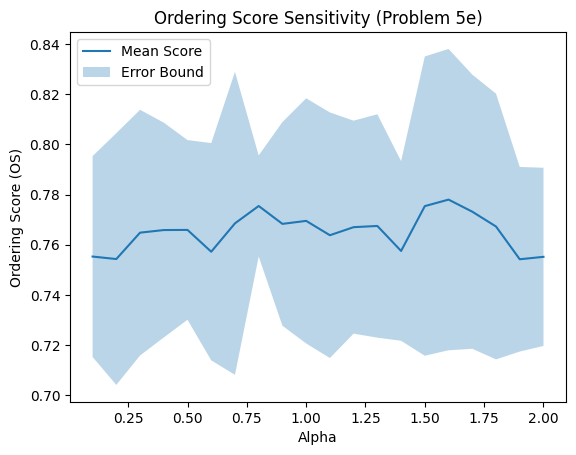

In [10]:
env = CityPlannerEnv('config/problems/problem_5e.yml')

alpha_range = [alpha / 10 for alpha in range(1, 21)]
all_scores = []

# Collect scores for seeds 0-4
for seed in range(5):
    scores = []
    for alpha in tqdm(alpha_range, desc=f"Seed {seed}"):
        scores.append(calculate_ordering_score(env, model_path=f'models/GraphAllocBench-Ordering/arch-0/problem_5e/{seed}/model_step_1000000.zip', alpha=alpha))
    all_scores.append(scores)

# Calculate mean and error bounds
all_scores = np.array(all_scores)
mean_scores = np.mean(all_scores, axis=0)
std_scores = np.std(all_scores, axis=0)

fluctuation_std = np.std(mean_scores)
print(f"Fluctuation Standard Deviation: {fluctuation_std}")
cv = fluctuation_std / np.mean(mean_scores)
print(f"Coefficient of Variation: {cv}")
# Plot mean and error bounds
plt.title("Ordering Score Sensitivity (Problem 5e)")
plt.xlabel("Alpha")
plt.ylabel("Ordering Score (OS)")
plt.plot(alpha_range, mean_scores, label='Mean Score')
plt.fill_between(alpha_range, mean_scores - std_scores, mean_scores + std_scores, alpha=0.3, label='Error Bound')
plt.legend()
plt.show()